# Introduction to Computational Physics: Problem Set 8
Tutorial: Chun Ming Yip (Group 3)

Document created by: Vencel Szabó, Finn Zeumer

In [9]:
from numpy.linalg import solve
import numpy as np
# import astropy.units as u
import matplotlib.pyplot as plt


In [10]:
# Setting Constans
G = 1
M_1 = 1
M_2 = 1

$\frac{d\vec{s}}{dt} = \vec{w}$

$\frac{d\vec{r}}{dt} = -\frac{\vec{s}}{s^3}$

where

$\vec{s} = \vec{v}/R_0, \qquad R_0 \text{ Mean Seperation }$

$\vec{\omega} = \vec{v}/v_0, \qquad \text{where } v_0 = \left(\dfrac{GM}{R_0}\right)$

$\tau = t/T_0, \qquad \text{where } T_0 = R_0/v_0 = \left( \dfrac{R_0^3}{GM} \right)^{1/2}$

# 1.1

In [11]:
def norm_r(r, R_0:float=1):
    return r/R_0

In [12]:
def norm_v(v, m:float = 1, R_0:float = 1):
    return v / np.sqrt(G * m / R_0)

In [13]:
def norm_t(t, R_0:float = 1, m:float = 1):
    return t / np.sqrt(R_0**2 / G / m)

The speed for each body is
$$w_0 = 1,$$
since we set the gravitational and the centripetal force equal at all point. 

The accerleration of the centipetal force is hence 
$$a_c = w_0^2/r.$$
And the gravitational acceleration
$$a_g = -\vec s / s^3 = GM/r^2 =w_0^2/r$$

Actually, we are just interested in the magnitude:
$$a_g = 1/ s^2$$

For an perfect ciruclar trajectory we need
$$a_g \overset{!}=a_c$$
thus
$$-1/ s^2 = w_0^2/r$$

With $s=1, r=1$ we get
$$w_0 = \sqrt{1} = 1$$


# 1.2 Euler's Method

We have a ODE of first order:
$$\frac{dy}{d\tau} = f(y,\tau)$$

with the initial conditions
$$y(0) = s_0$$
and
$$y'(0) = w_0$$

## Approximate solution 
$$\bar{y}_{i+1} = \bar{y}_i + h\cdot f(\bar{y}_i, \tau)$$

where the bar indicateds that we jsut have an approximation and 
$$h=t_{i+1}-t_i = \frac{a-b}{N} = \Delta \tau$$
is the stepsize/gridsize. The intervall is $[a,b]$ and the mesh contains $N$ cells/points.

In [80]:
# INITIAL CONDITIONS AND CONSTANTS
#Timesteps
delta_tau = 0.01
# total time
t_tot = 10
# steps
N_steps = int(t_tot/delta_tau)

# INITIAL CONDITIONS
# The starting seperation y(0)
s_0 = [1,0]
# the sarting velocity y'(0)
w_0 = [0,1] # must be perpendicular to s_0

In [109]:
# def eulerSolving_twoBodyTwoD(
#         s_0:np.ndarray = np.array([1,0]), 
#         w_0:np.ndarray = np.array([0,1]), 
#         total_time:float = 100,
#         time_step:float = 0.01
#         ):
#     '''
#     Method defining dy/dtau = f(y)

#     params
#     ______
#     s_0 : np.ndarray (1 x 2)
#         initial seperation of the two bodys
#     w_0 : np.ndarray (1 x 2)
#         inital relativ velocity

#     returns
#     _______

#     '''
#     # calculating the stepzise by given parameters
#     steps = int(t_tot/delta_tau)
    
#     # Initialize storage
#     s_history = np.zeros((steps, 4))

#     # Calculating distance between the two bodies
#     dist = np.sqrt(np.sum(np.square(s_0)))
#     if dist == 0:
#         raise ValueError('The distance between the bodies must be lagrer than 0.')


#     # Summerizing inital conditions
#     def calc_step(w, s):

#         # Calculationg the accerleration
#         acc_fac = -1 / (dist**3)

#         # The velocity does not change
#         ds_dtau = w_0
#         dw_dtau = acc_fac * s_0

#         # Finial value to return
#         y_res = np.concatenate([ds_dtau, dw_dtau], axis=0)
#         s_history[0] = y_res # Adding starting values
#         return y_res
    
#     # loop to get the results for every step
#     for i in range(1, steps):
#         current_y = s_history[i-1]

#         # Calcuate derivertive f(y) = dy/dt
#         dy_dt = calc_step(current_y)

#         # Euler Step: y_{n+1} = y_n + dt * f(y_n)
#         s_history[i] = current_y + time_step * dy_dt


#     return s_history

In [150]:
def eulerSolving_twoBodyTwoD(
        s_0:np.ndarray = np.array([1,0]), 
        w_0:np.ndarray = np.array([0,1]), 
        total_time:float = 20,
        time_step:float = 0.01
        ):
    '''
    Method defining dy/dtau = f(y)

    params
    ______
    s_0 : np.ndarray (1 x 2)
        initial seperation of the two bodys
    w_0 : np.ndarray (1 x 2)
        inital relativ velocity

    returns
    _______

    '''
    # calculating the stepzise by given parameters
    steps = int(total_time/delta_tau)
    
    # Initialize storage
    s_history = np.zeros((steps, 4))

    # Calculating distance between the two bodies
    dist = np.sqrt(np.sum(np.square(s_0)))
    if dist <= 1e-15:
        raise ValueError('The distance between the bodies must be lagrer than 0.')
    
    # Calculationg the accerleration factor
    acc_fac = -1 / (dist**3)

    # Summerizing inital conditions
    def calc_step(y):
        s = y[0:2]
        w = y[2:4]

        ds_dtau = w
        dw_dtau = acc_fac * s

        # Finial value to return
        y_temp = np.concatenate([ds_dtau, dw_dtau], axis=0)
        return y_temp
    

    # Calculating starting position
    y_start = np.concatenate([s_0, w_0], axis=0)
    y_0 = calc_step(y_start)
    s_history[0] = y_0
    print(y_start)
    # loop to get the results for every step
    for i in range(1, steps):
        current_y = s_history[i-1]

        # Calcuate derivertive f(y) = dy/dt
        dy_dt = calc_step(current_y)

        # Euler Step: y_{n+1} = y_n + dt * f(y_n)
        s_history[i] = current_y + time_step * dy_dt


    return s_history

[1 0 0 1]


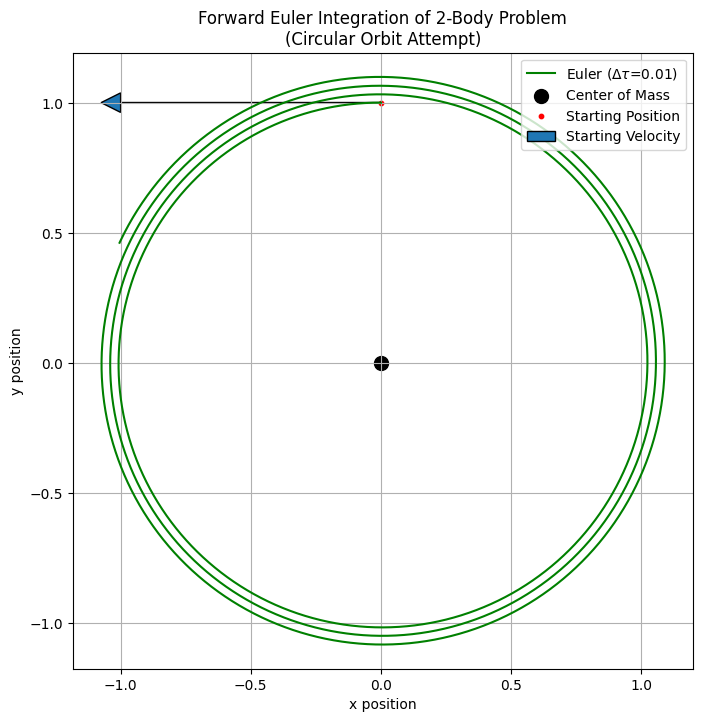

In [157]:
params = eulerSolving_twoBodyTwoD()
x_pos = params[:,0]
y_pos = params[:,1]
x_velo = params[:,2]
y_velo = params[:,3]

# --- Plotting the Result (Task 2) ---
plt.figure(figsize=(8, 8))
ax = plt.axes()
ax.plot(
    x_pos,
    y_pos, 
    label=fr'Euler ($\Delta\tau$={delta_tau})', 
    color='green'
    )

ax.scatter([0], [0], color='black', s=100, label='Center of Mass')
ax.scatter(x_pos[0], y_pos[0], color='red', s=10, label='Starting Position')
ax.arrow(x_pos[0], y_pos[0], x_velo[0], y_velo[0], head_width=0.075, head_length=0.075, label='Starting Velocity')

plt.title('Forward Euler Integration of 2-Body Problem\n(Circular Orbit Attempt)')
plt.xlabel('x position')
plt.ylabel('y position')
plt.axis('equal') # Crucial for visualizing circle vs spiral
plt.grid(True)
plt.legend(loc='upper right')
plt.show()

# 1.3

# 1.4